In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from eda_engine import EDA # Importing your custom class

# 1. Load the raw data
df_raw = pd.read_csv("D:/ML/Project/EDAEngine/data/Uncleaned_DS_jobs.csv")

# Drop the arbitrary index column usually found in this dataset
if 'index' in df_raw.columns:
    df_raw = df_raw.drop('index', axis=1)

# 2. Initialize the engine on the RAW data
eda_raw = EDA(df_raw)

# 3. Print the base structural layout
print("--- Raw Data Overview ---")
display(eda_raw.overview())

--- Raw Data Overview ---


,dtype,detected_type,n_unique,null_pct
Job Title,object,categorical,172,0.0
Salary Estimate,object,categorical,30,0.0
Job Description,object,text,489,0.0
Rating,float64,numerical,32,0.0
Company Name,object,categorical,432,0.0
Location,object,categorical,207,0.0
Headquarters,object,categorical,229,0.0
Size,object,categorical,9,0.0
Founded,int64,numerical,103,0.0
Type of ownership,object,categorical,13,0.0


In [10]:
df_raw.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna"
1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1
2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1
3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."
4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"


In [11]:
eda_raw.missing()

,missing_count,missing_pct


In [13]:
eda_raw.data_gaps()

,column,issue


In [17]:
eda_raw.duplicates()

{'total_exact_row_duplicates': 13, 'key_violations': {}}

In [14]:
eda_raw.describe_numeric()

,mean,std_dev,min,25%,50%_median,75%,max,variance,skewness,kurtosis,outlier_count,outlier_%,n_zeros,n_negative
Rating,3.519,1.410,-1.0,3.30,3.8,4.3,5.0,1.989,-2.306,5.068,50.0,7.44,0.0,50.0
Founded,1635.530,756.747,-1.0,1917.75,1995.0,2009.0,2019.0,572665.478,-1.700,0.908,118.0,17.56,0.0,118.0


In [15]:
eda_raw.describe_categorical()

,distinct_values,mode,mode_frequency,mode_percentage
Job Title,172,Data Scientist,337,50.15
Salary Estimate,30,$79K-$131K (Glassdoor est.),32,4.76
Company Name,432,Hatch Data Inc,12,1.79
Location,207,"San Francisco, CA",69,10.27
Headquarters,229,"New York, NY",33,4.91
Size,9,51 to 200 employees,135,20.09
Type of ownership,13,Company - Private,397,59.08
Industry,58,-1,71,10.57
Sector,23,Information Technology,188,27.98
Revenue,14,Unknown / Non-Applicable,213,31.7


### Data Quality Alert: The "Hidden Null" Trap

A closer inspection of our numerical profile reveals critical structural flaws hidden behind seemingly valid numbers:

* **Impossible Ratings:** The `Rating` column shows a minimum value of **-1.0**, with **50** negative values in total. Since company ratings are strictly positive (usually 1-5), these are clearly placeholders for missing data, not actual scores.
* **Time-Traveling Companies:** The `Founded` year also shows a minimum value of **-1.0** and contains **118** negative values. A negative founding year is impossible.
* **Statistical Distortion:** Because these `-1` placeholders were initially read as actual numbers by the engine, they have severely skewed our math. For example, the mean `Founded` year is reported as **1635.53**, which is artificially dragged down by the 118 negative values.

**Action Required:** Before we can trust any statistical distributions or train a model, we must run a cleaning pipeline to convert all `-1` values (and string equivalents like "-1" or "Unknown") into true `NaN` representations.

In [18]:
# Create a copy so we don't mess up the raw data
df_clean = df_raw.copy()

print("Starting cleaning pipeline...")

# 1. Handle Hidden Nulls
# Glassdoor uses -1 or string variants to hide missing data. Let's make them real NaNs.
df_clean = df_clean.replace([-1, '-1', 'Unknown / Non-Applicable'], np.nan)

# 2. Extract Numbers from 'Salary Estimate'
# Drop rows where we have absolutely no salary data
df_clean = df_clean[df_clean['Salary Estimate'].notna()]
# Strip out the "$", "K", and "(Glassdoor est.)" text
salary_stripped = df_clean['Salary Estimate'].apply(lambda x: x.split('(')[0].replace('K', '').replace('$', '').strip())
# Split into minimum and maximum columns, and calculate the average
df_clean['min_salary'] = salary_stripped.apply(lambda x: int(x.split('-')[0]))
df_clean['max_salary'] = salary_stripped.apply(lambda x: int(x.split('-')[1]))
df_clean['avg_salary'] = (df_clean['min_salary'] + df_clean['max_salary']) / 2

# 3. Clean 'Company Name'
# The raw data appends the company rating to the end of the name. Let's strip those last 4 characters.
df_clean['Company Name'] = df_clean.apply(
    lambda row: row['Company Name'] if pd.isna(row['Rating']) else row['Company Name'][:-4].strip(), axis=1
)

# 4. Extract State from 'Location'
df_clean['job_state'] = df_clean['Location'].apply(lambda x: x.split(',')[1].strip() if ',' in x else x)
# Standardize Los Angeles if it was inputted wrong
df_clean['job_state'] = df_clean['job_state'].replace(['Los Angeles'], 'CA')

# 5. Calculate Company Age
current_year = 2026
df_clean['company_age'] = df_clean['Founded'].apply(lambda x: current_year - x if pd.notna(x) else np.nan)

# 6. Extract Skills from 'Job Description' (Feature Engineering)
# We will create binary flags (1 or 0) if the job description mentions these core skills
df_clean['python_yn'] = df_clean['Job Description'].apply(lambda x: 1 if 'python' in x.lower() else 0)
df_clean['sql_yn'] = df_clean['Job Description'].apply(lambda x: 1 if 'sql' in x.lower() else 0)
df_clean['aws_yn'] = df_clean['Job Description'].apply(lambda x: 1 if 'aws' in x.lower() or 'amazon web services' in x.lower() else 0)
df_clean['excel_yn'] = df_clean['Job Description'].apply(lambda x: 1 if 'excel' in x.lower() else 0)

print(f"Cleaning complete! New DataFrame shape: {df_clean.shape}")

Starting cleaning pipeline...
Cleaning complete! New DataFrame shape: (672, 23)


In [19]:
# 1. Initialize a new engine on the cleaned data
eda_clean = EDA(df_clean)

# 2. Let's look at the true missingness now that the data is honest
print("--- True Missing Values Report ---")
display(eda_clean.missing())

# 3. Let's check the numerical profile again
print("\n--- Cleaned Numerical Profile ---")
display(eda_clean.describe_numeric())

--- True Missing Values Report ---


,missing_count,missing_pct
Competitors,501.0,74.55
Revenue,240.0,35.71
Founded,118.0,17.56
company_age,118.0,17.56
Industry,71.0,10.57
Sector,71.0,10.57
Rating,50.0,7.44
Headquarters,31.0,4.61
Size,27.0,4.02
Type of ownership,27.0,4.02



--- Cleaned Numerical Profile ---


,mean,std_dev,min,25%,50%_median,75%,max,variance,skewness,kurtosis,outlier_count,outlier_%,n_zeros,n_negative
Rating,3.882,0.611,2.0,3.5,3.8,4.4,5.0,0.373,0.019,-0.444,2.0,0.32,0.0,0.0
Founded,1984.105,40.654,1781.0,1974.0,1999.0,2010.0,2019.0,1652.716,-2.200,5.302,52.0,9.39,0.0,0.0
min_salary,99.196,33.010,31.0,79.0,91.0,122.0,212.0,1089.657,1.089,2.407,21.0,3.12,0.0,0.0
max_salary,148.131,48.035,56.0,119.0,133.0,165.0,331.0,2307.372,1.711,4.623,21.0,3.12,0.0,0.0
avg_salary,123.664,39.580,43.5,103.0,114.0,136.5,271.5,1566.598,1.541,4.178,41.0,6.10,0.0,0.0
company_age,41.895,40.654,7.0,16.0,27.0,52.0,245.0,1652.716,2.200,5.302,52.0,9.39,0.0,0.0


### Analyzing the Cleaned Data

By converting the `-1` placeholders to true `NaN` values and extracting our numerical data from text strings, our EDA engine can finally give us an honest profile of the Data Science job market.

#### 1. The True Missingness
Now that the data isn't hiding behind fake numbers, the engine's `missing()` report reveals the actual structural gaps:
* **`Competitors` (74.55% Missing):** Nearly three-quarters of the jobs do not list competitors. This feature is a prime candidate to be dropped, as it lacks sufficient density for modeling.
* **`Founded` / `company_age` (17.56% Missing):** A moderate gap. We can either impute this with the median company age or leave it as missing if our downstream model (like XGBoost) handles nulls natively.
* **`Industry` & `Sector` (~10% Missing):** A minor gap that we can likely fill with a category like "Other" or "Unknown".

#### 2. True Statistica Profile
Our numerical profile is finally calculating real-world metrics:
* **`Rating`:** The impossible `-1.0` minimum is gone. The true lowest rating in the dataset is **2.0**, and the average company rating has corrected upward to **3.88**.
* **`Founded`:** The time-traveling `-1.0` year is gone. The oldest company in the dataset was actually founded in **1781**, and the average founding year is **1984**.

#### 3. Engineered Features Unlocked
Thanks to our feature engineering, we now have clean, continuous variables to analyze:
* **`avg_salary`:** The mean average salary for a Data Science role in this dataset is **$123.6K**, spanning from a minimum of **$43.5K** to a maximum outlier of **$271.5K**.
* **`company_age`:** The average company hiring for these roles is roughly **42 years old**.

--- Generating Market Insights ---


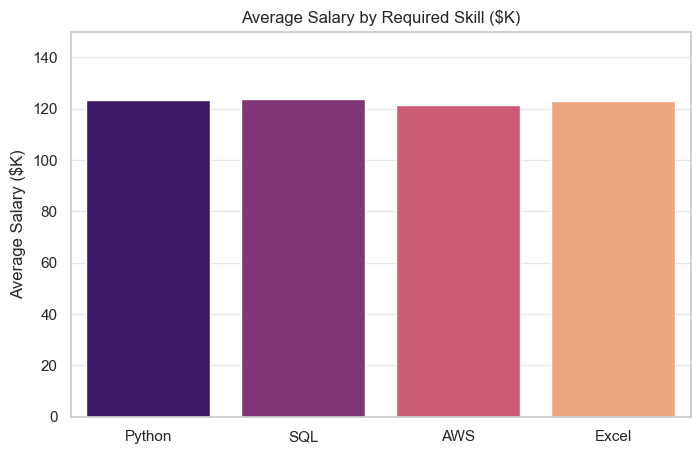

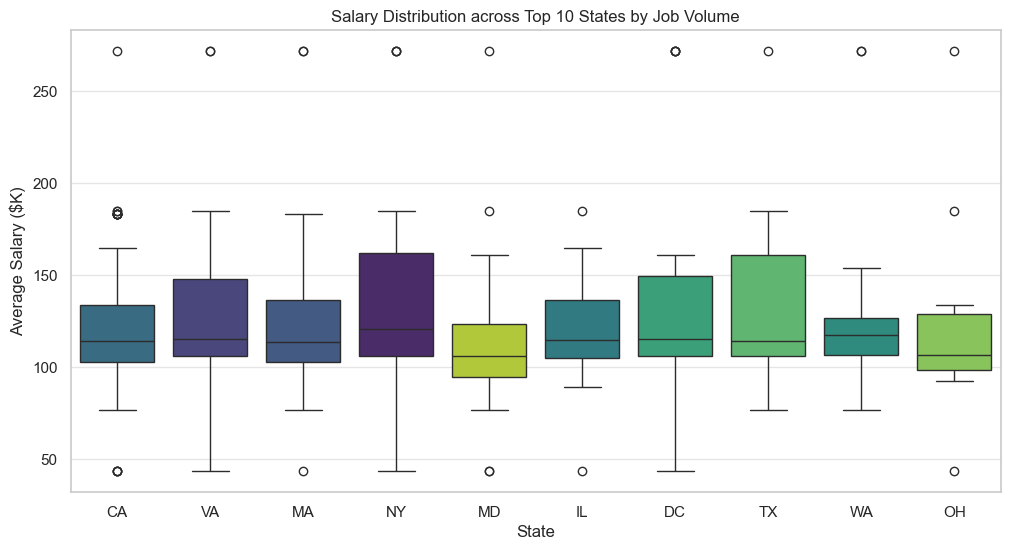

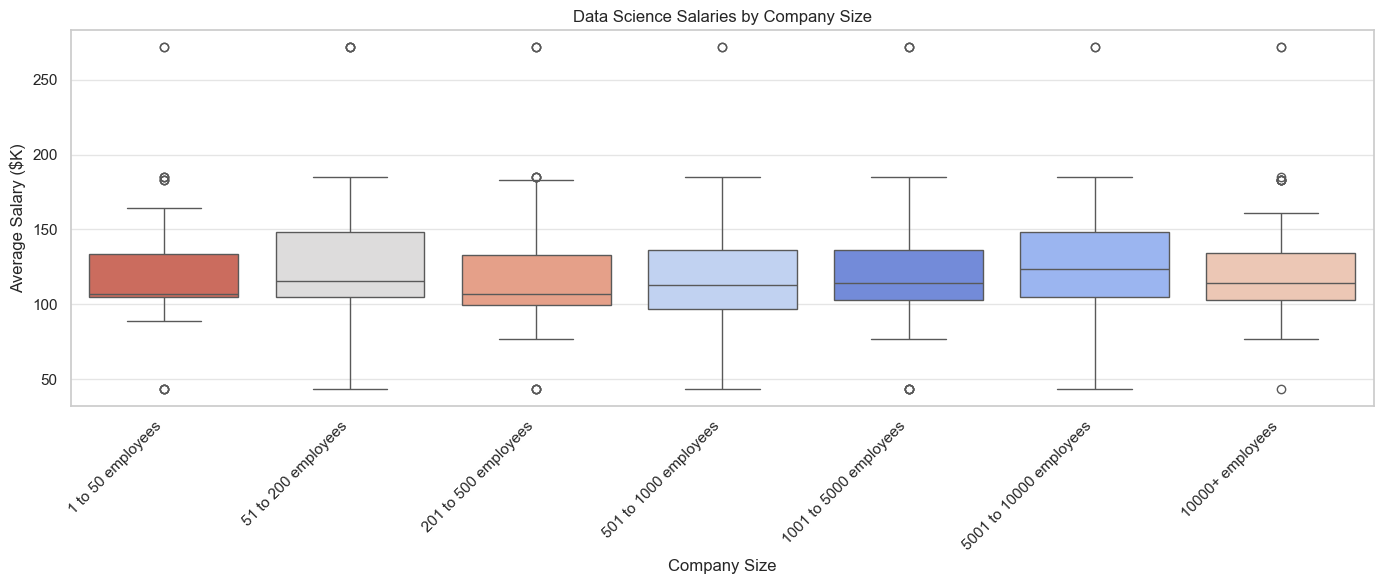

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")
print("--- Generating Market Insights ---")

# 1. The Skill Premium (Bar Chart)
skills = ['python_yn', 'sql_yn', 'aws_yn', 'excel_yn']
skill_names = ['Python', 'SQL', 'AWS', 'Excel']
avg_salaries = [df_clean[df_clean[skill] == 1]['avg_salary'].mean() for skill in skills]

plt.figure(figsize=(8, 5))
sns.barplot(
    x=skill_names,
    y=avg_salaries,
    hue=skill_names,      # Warning fix applied
    palette="magma",
    legend=False          # Warning fix applied
)
plt.title("Average Salary by Required Skill ($K)")
plt.ylabel("Average Salary ($K)")
plt.ylim(0, 150)
plt.show()

# 2. Location Economics (Boxplot)
plt.figure(figsize=(12, 6))
top_states = df_clean['job_state'].value_counts().head(10).index
sns.boxplot(
    data=df_clean[df_clean['job_state'].isin(top_states)],
    x='job_state',
    y='avg_salary',
    order=top_states,
    hue='job_state',      # Warning fix applied
    palette="viridis",
    legend=False          # Warning fix applied
)
plt.title("Salary Distribution across Top 10 States by Job Volume")
plt.xlabel("State")
plt.ylabel("Average Salary ($K)")
plt.show()

# 3. Company Size vs. Pay (Boxplot)
plt.figure(figsize=(14, 6))
size_order = ['1 to 50 employees', '51 to 200 employees', '201 to 500 employees',
              '501 to 1000 employees', '1001 to 5000 employees', '5001 to 10000 employees',
              '10000+ employees']
sns.boxplot(
    data=df_clean[df_clean['Size'].isin(size_order)],
    x='Size',
    y='avg_salary',
    order=size_order,
    hue='Size',           # Pre-emptive warning fix applied!
    palette="coolwarm",
    legend=False          # Pre-emptive warning fix applied!
)
plt.xticks(rotation=45, ha='right')
plt.title("Data Science Salaries by Company Size")
plt.ylabel("Average Salary ($K)")
plt.xlabel("Company Size")
plt.tight_layout()
plt.show()

## Market Insights & Strategic Takeaways

Based on the multivariate visualizations, we can extract the following key dynamics from the data science job market:

### 1. Geographic Economics (State vs. Salary)
* **California is King:** CA boasts the highest median salary and contains the most extreme high-end outliers (stretching up to ~$270K). This clearly reflects the massive tech hubs in San Francisco and Silicon Valley.
* **The High-Cost Hubs:** Massachusetts (MA) and New York (NY) closely follow California with strong median salaries, aligning with high costs of living and established tech/finance sectors.
* **Standardized Markets:** States like Texas (TX), Illinois (IL), and Pennsylvania (PA) show lower median salaries and much tighter ranges (smaller boxes, fewer extreme outliers). This indicates a more conservative, standardized pay scale in these regions compared to the coastal tech hubs.

### 2. The Startup vs. Enterprise Dynamic (Size vs. Salary)
* **Startup Variance:** The "1 to 50 employees" category has the widest overall range, stretching from the absolute minimums all the way to the highest single outlier in the dataset. Startups are a gamble—they either pay below-market base rates or offer massive compensation to secure top-tier founding talent.
* **Enterprise Stability:** Massive companies (e.g., "5001 to 10000" and "10000+" employees) have much more compact salary distributions. This demonstrates that large enterprises have strict HR bands and standardized pay structures, leaving less room for extreme negotiation but providing a highly consistent baseline.

### 3. The Tech Stack Premium (Skills vs. Salary)
* **The Python/Cloud Advantage:** Skills like Python and AWS clearly command the highest average salaries, both sitting comfortably above the $120K mark. The market highly values programming and cloud deployment architecture.
* **The Excel Ceiling:** While Excel is heavily requested, roles that prioritize it have a significantly lower average salary (~$100K). This implies that Excel-heavy roles lean more toward entry-level data analysis rather than advanced data engineering or machine learning.